# PROJETO TURMA 1629 TECNICAS DE PROGRAMAÇÃO
# MARCOS ANTONIO DA SILVA Id: 1629010

Projeto Final: Técnicas de Programação com Python e Pandas
Análise de Perfil e Tendências do Mercado de Desenvolvimento no Brasil (2025)

Este projeto aplica técnicas de tratamento e análise de dados sobre o dataset do Stack Overflow Annual Developer Survey. O foco da análise está restrito aos respondentes do Brasil, explorando variáveis como remuneração, tecnologias (Python, C#), modelos de trabalho e escolaridade, com o objetivo de extrair insights sobre a realidade do desenvolvedor brasileiro.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar apenas os dados do Brasil
df_brasil = pd.read_csv('survey_results_brazil.csv')



Descrição de dados


Nesta etapa, vamos explorar a estrutura do dataset filtrado para o Brasil, 
verificando tipos de variáveis, dimensões e a presença de dados nulos.

Resumo das principais colunas usadas

Perfil: Age, EdLevel, YearsCode, DevType.

Trabalho: RemoteWork, OpSysProfessional use.

Tecnologia: LanguageHaveWorkedWith, PlatformHaveWorkedWith.

Financeiro: ConvertedCompYearly.

In [21]:
# Dimensões do dataset (Linhas, Colunas)
print(f"O dataset possui {df_brasil.shape[0]} linhas e {df_brasil.shape[1]} colunas.")

# Listar as colunas e tipos de dados
print("\n--- Tipos de Dados ---")
print(df_brasil.dtypes)

# Verificar valores nulos (importante para o Passo 3)
print("\n--- Valores Nulos por Coluna ---")
print(df_brasil.isnull().sum())

# Ver as primeiras 5 linhas para entender o conteúdo
df_brasil.head()

O dataset possui 825 linhas e 172 colunas.

--- Tipos de Dados ---
ResponseId               int64
MainBranch              object
Age                     object
EdLevel                 object
Employment              object
                        ...   
AIAgentExtWrite         object
AIHuman                 object
AIOpen                  object
ConvertedCompYearly    float64
JobSat                 float64
Length: 172, dtype: object

--- Valores Nulos por Coluna ---
ResponseId               0
MainBranch               0
Age                      0
EdLevel                  2
Employment               0
                      ... 
AIAgentExtWrite        800
AIHuman                151
AIOpen                 317
ConvertedCompYearly    186
JobSat                 200
Length: 172, dtype: int64


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,21,"I am not primarily a developer, but I write co...",55-64 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,None of the above,40.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","No, I learned something that was not related t...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,85,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",15.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I want to fully understand something;When...,Imagination and problem-solving. AI is only ca...,36407.0,10.0
2,155,"I am not primarily a developer, but I write co...",45-54 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,Transitioning to retirement (gradually reducin...,32.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,Zapier,NaN,NaN,NaN,ChatGPT;GitHub Copilot,NaN,When I don’t trust AI’s answers;When I want to...,"creativity, understanding requisites",91018.0,NaN
3,203,I am a developer by profession,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","No, I learned something that was not related t...",...,NaN,NaN,NaN,NaN,ChatGPT;GitHub Copilot,NaN,When I don’t trust AI’s answers;When I want to...,"Planning, QA and UI/UX development",41765.0,10.0
4,285,I am a developer by profession,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,25.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools req...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Microsoft C...,NaN,When I want to learn best practices;When I’m s...,decision-making of sw architectures,NaN,8.0


In [22]:
# Removendo valores nulos na coluna de salário
df_brasil = df_brasil.dropna(subset=['ConvertedCompYearly'])

# Removendo colunas que são constantes ou inúteis para esta análise
# (Exemplo: se a coluna 'Country' agora é só 'Brazil', ela é constante)
df_brasil = df_brasil.drop(columns=['Country'])

print(f"Dados tratados! Agora restam {df_brasil.shape[0]} registros.")

Dados tratados! Agora restam 639 registros.


In [23]:
#  Ver os valores únicos para identificar os textos
print(df_brasil['YearsCode'].unique())

#  Substituir textos por valores numéricos
# "Less than 1 year" vira 0 e "More than 50 years" vira 51
df_brasil['YearsCode'] = df_brasil['YearsCode'].replace({'Less than 1 year': 0, 'More than 50 years': 51})

#  Converter a coluna para numérico (forçando erros a virarem NaN para não travar o código)
df_brasil['YearsCode'] = pd.to_numeric(df_brasil['YearsCode'], errors='coerce')

#  Remover linhas que ficaram vazias após a conversão 
df_brasil = df_brasil.dropna(subset=['YearsCode'])

print("Coluna YearsCode convertida com sucesso!")

[ 15.  37.   7.  30.  20.  26.   8.  35.  18.   4.  17.  14.  42.  22.
  21.  19.  32.  29.   6.  10.  13.  28.  25.  24.   5.  50.  23.  16.
  12.   3.   2.   9.  11.  40.  27.  31.  39.  34.  nan   1. 100.  33.
  38.  45.  41.]
Coluna YearsCode convertida com sucesso!


In [24]:
# Definindo os limites (removendo os 5% menores e 5% maiores salários) evitando erros discrepantes 
limite_inferior = df_brasil['ConvertedCompYearly'].quantile(0.05)
limite_superior = df_brasil['ConvertedCompYearly'].quantile(0.95)

# Filtrando o DataFrame
df_brasil = df_brasil[(df_brasil['ConvertedCompYearly'] >= limite_inferior) & 
                      (df_brasil['ConvertedCompYearly'] <= limite_superior)]

print(f"Outliers removidos! Faixa salarial mantida: ${limite_inferior:,.2f} a ${limite_superior:,.2f}")

Outliers removidos! Faixa salarial mantida: $1,573.00 a $118,032.80


# Pergunta 1: Qual a média salarial dos desenvolvedores que usam Python vs. C# no Brasil?

In [25]:
# 1. Filtrar quem usa Python e quem usa C# (usando str.contains)
# O case=False ignora maiúsculas/minúsculas, o na=False trata nulos
python_users = df_brasil[df_brasil['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)]
csharp_users = df_brasil[df_brasil['LanguageHaveWorkedWith'].str.contains('C#', case=False, na=False)]

# 2. Calcular as médias salariais (usando a coluna convertida no Passo 3)
media_python = python_users['ConvertedCompYearly'].mean()
media_csharp = csharp_users['ConvertedCompYearly'].mean()

print(f"Média Salarial Anual (Python): US$ {media_python:,.2f}")
print(f"Média Salarial Anual (C#):     US$ {media_csharp:,.2f}")



Média Salarial Anual (Python): US$ 33,203.78
Média Salarial Anual (C#):     US$ 34,436.30


# Pergunta 2: Qual a distribuição dos modelos de trabalho (Remoto, Híbrido, Presencial) entre os devs no Brasil?

In [26]:
# 1. Contar a frequência de cada modelo de trabalho na coluna 'RemoteWork'
distribuicao_trabalho = df_brasil['RemoteWork'].value_counts()

# 2. Calcular a porcentagem
porcentagem_trabalho = df_brasil['RemoteWork'].value_counts(normalize=True) * 100

print("--- Distribuição de Trabalho no Brasil ---")
print(distribuicao_trabalho)
print("\n--- Porcentagem ---")
print(porcentagem_trabalho.round(2).astype(str) + '%')



--- Distribuição de Trabalho no Brasil ---
RemoteWork
Remote                                                                          257
In-person                                                                        73
Hybrid (some in-person, leans heavy to flexibility)                              67
Hybrid (some remote, leans heavy to in-person)                                   58
Your choice (very flexible, you can come in when you want or just as needed)     40
Name: count, dtype: int64

--- Porcentagem ---
RemoteWork
Remote                                                                          51.92%
In-person                                                                       14.75%
Hybrid (some in-person, leans heavy to flexibility)                             13.54%
Hybrid (some remote, leans heavy to in-person)                                  11.72%
Your choice (very flexible, you can come in when you want or just as needed)     8.08%
Name: proportion, dtype: object


# Pergunta 3: Qual a média salarial por nível de educação no Brasil?

In [27]:
# Agrupamos por educação, pegamos o salário, tiramos a média e arredondamos
resultado_edu = df_brasil.groupby('EdLevel')['ConvertedCompYearly'].mean().round(2)

print("Média Salarial Anual escolaridade (Arredondado):")
print(resultado_edu)


Média Salarial Anual escolaridade (Arredondado):
EdLevel
Associate degree (A.A., A.S., etc.)                                                   35142.10
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          36848.30
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       43076.92
Other (please specify):                                                               32698.14
Primary/elementary school                                                              6431.67
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        32506.61
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    24991.30
Some college/university study without earning a degree                                23632.20
Name: ConvertedCompYearly, dtype: float64


# Pergunta 4: Anos de Experiência vs. Salário

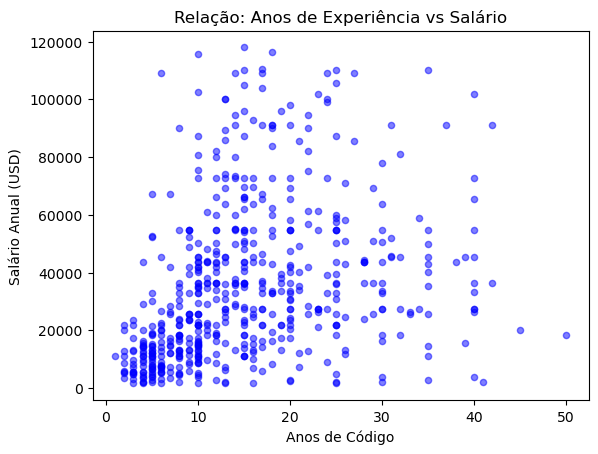

In [29]:
# 1. Criar um gráfico de dispersão
# Cada ponto no gráfico representa um programador brasileiro
df_brasil.plot(kind='scatter', x='YearsCode', y='ConvertedCompYearly', alpha=0.5, color='blue')

# 2. Configurar o título
plt.title('Relação: Anos de Experiência vs Salário')
plt.xlabel('Anos de Código')
plt.ylabel('Salário Anual (USD)')
plt.show()

# Pergunta 5: Média Salarial por Tipo de Desenvolvedor

Top 10 Cargos com Maiores Salários no Brasil:
DevType
DevOps engineer or professional          75581.60
Product manager                          67354.00
Engineering manager                      52746.57
Architect, software or solutions         49102.86
Developer, QA or test                    44484.00
Developer, mobile                        43607.87
Project manager                          41822.75
Cloud infrastructure engineer            40605.00
Cybersecurity or InfoSec professional    38228.00
AI/ML engineer                           37454.25
Name: ConvertedCompYearly, dtype: float64


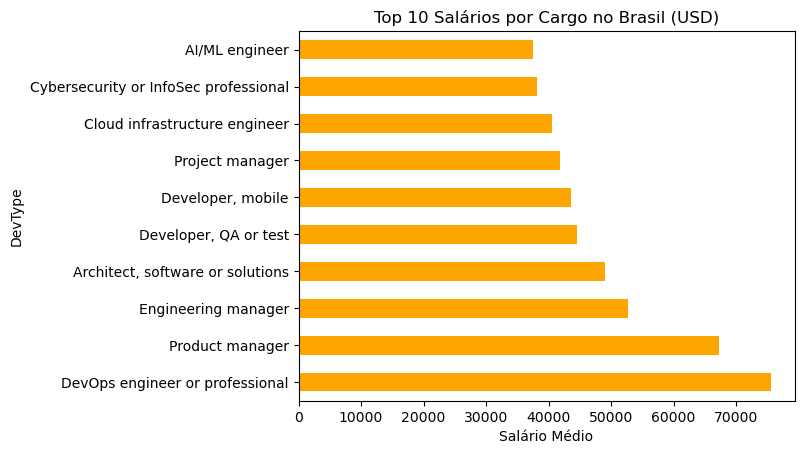

In [31]:
# 1. Agrupar por cargo e calcular a média salarial com 2 casas decimais
salario_por_cargo = df_brasil.groupby('DevType')['ConvertedCompYearly'].mean().round(2)

# 2. Ordenar do maior para o menor para facilitar a leitura
salario_por_cargo = salario_por_cargo.sort_values(ascending=False)

# 3. Mostrar os 10 cargos que ganham mais (os top 10)
print("Top 10 Cargos com Maiores Salários no Brasil:")
print(salario_por_cargo.head(10))

# 4. Criar um gráfico de barras horizontal (barh)
salario_por_cargo.head(10).plot(kind='barh', color='orange')
plt.title('Top 10 Salários por Cargo no Brasil (USD)')
plt.xlabel('Salário Médio')
plt.show()

# Pergunta 6: Desenvolvedores Python ganham mais do que a média dos outros desenvolvedores no Brasil?

Comparativo Salarial - Python no Brasil:
Não usa Python    36817.52
Usa Python        33203.78
Name: ConvertedCompYearly, dtype: float64


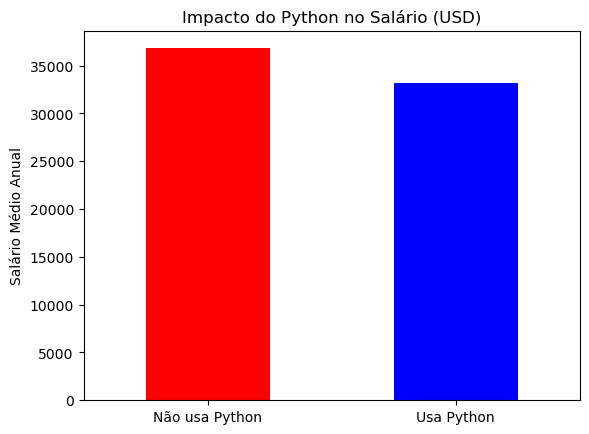

In [33]:
# 1. Criar uma coluna nova que diz se a pessoa usa Python ou não
# Se 'Python' estiver na coluna 'LanguageHaveWorkedWith', vira True, senão False
df_brasil['Usa_Python'] = df_brasil['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)

# 2. Agrupar por essa nova coluna e calcular a média salarial
comparativo_python = df_brasil.groupby('Usa_Python')['ConvertedCompYearly'].mean().round(2)

# 3. Renomear os índices revisados em aula para melhorar aparencia no print e no gráfico
comparativo_python.index = ['Não usa Python', 'Usa Python']

print("Comparativo Salarial - Python no Brasil:")
print(comparativo_python)

# 4. Gráfico de barras simples
comparativo_python.plot(kind='bar', color=['red', 'blue'], title='Impacto do Python no Salário (USD)')
plt.ylabel('Salário Médio Anual')
plt.xticks(rotation=0) # Deixa o texto do eixo X reto
plt.show()

# 5. observação: Acredito que essa questão mereça mais atenção devido a ninchos mercadológicos de linguagens e particularidades que a pesquisa talvez não aborde ou falha na análise aplicada.

# Pergunta 7: Idade e Salário (Agrupamento por Faixa Etária)

Média Salarial por Faixa Etária no Brasil:
Age
35-44 years old      43764.57
45-54 years old      37728.41
25-34 years old      34411.57
55-64 years old      33914.77
65 years or older    14563.00
18-24 years old      11053.25
Name: ConvertedCompYearly, dtype: float64


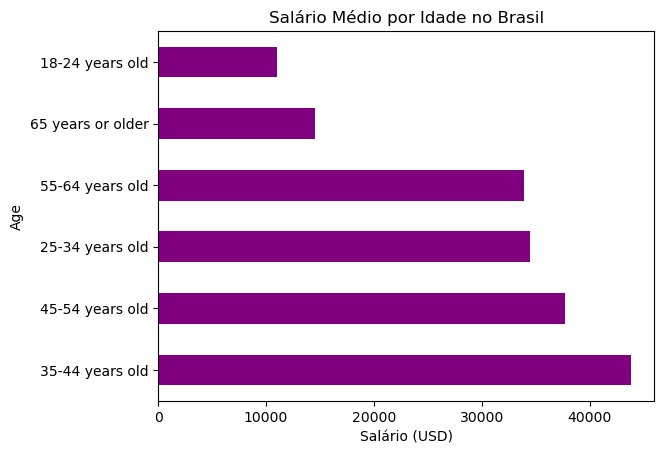

In [34]:
# 1. Agrupar pela coluna 'Age' e tirar a média arredondada
salario_por_idade = df_brasil.groupby('Age')['ConvertedCompYearly'].mean().round(2)

# 2. Ordenar os valores para ver quem ganha mais no topo
salario_por_idade = salario_por_idade.sort_values(ascending=False)

print("Média Salarial por Faixa Etária no Brasil:")
print(salario_por_idade)

# 3. Gráfico de barras horizontal
salario_por_idade.plot(kind='barh', color='purple', title='Salário Médio por Idade no Brasil')
plt.xlabel('Salário (USD)')
plt.show()

# Pergunta 8: Qual a porcentagem de desenvolvedores no Brasil que usam C#?

Porcentagem de uso de C# no Brasil:
Não usa C#     75.03999999999999%
Usa C#        24.959999999999997%
Name: proportion, dtype: object


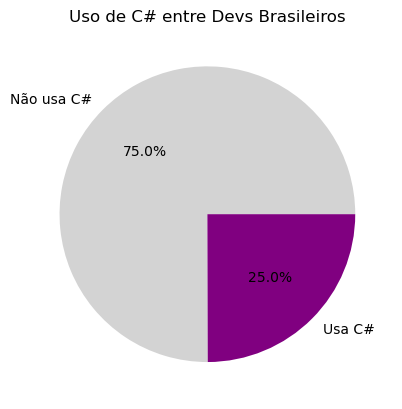

In [35]:
# 1. Criar coluna para identificar quem usa C#
df_brasil['Usa_C#'] = df_brasil['LanguageHaveWorkedWith'].str.contains('C#', case=False, na=False)

# 2. Contar quantos usam e quantos não usam (em porcentagem)
porcentagem_csharp = df_brasil['Usa_C#'].value_counts(normalize=True).round(4) * 100

# 3. Renomear para o gráfico
porcentagem_csharp.index = ['Não usa C#', 'Usa C#']

print("Porcentagem de uso de C# no Brasil:")
print(porcentagem_csharp.astype(str) + '%')

# 4. Gráfico de Pizza
porcentagem_csharp.plot(kind='pie', autopct='%1.1f%%', title='Uso de C# entre Devs Brasileiros', colors=['lightgray', 'purple'])
plt.ylabel('')
plt.show()

# Observação: Exemplo de gráfico a ser evitado como fui severamente alertado em aula. :)

# Pergunta 9: Qual o Sistema Operacional (OpSys) mais popular no Brasil?

Top 5 Sistemas Operacionais no Brasil:
OpSysProfessional use
Windows                                             73
MacOS                                               59
Ubuntu                                              38
Windows;Windows Subsystem for Linux (WSL)           35
Windows;Ubuntu;Windows Subsystem for Linux (WSL)    17
Name: count, dtype: int64


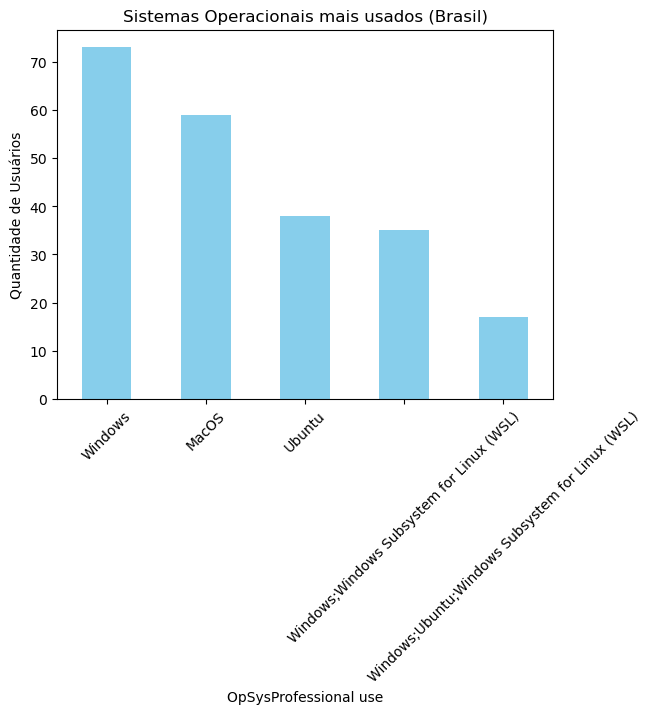

In [36]:
# 1. Contar os valores da coluna correta
so_popular = df_brasil['OpSysProfessional use'].value_counts().head(5)

print("Top 5 Sistemas Operacionais no Brasil:")
print(so_popular)

# 2. Gráfico
so_popular.plot(kind='bar', color='skyblue', title='Sistemas Operacionais mais usados (Brasil)')
plt.ylabel('Quantidade de Usuários')
plt.xticks(rotation=45)
plt.show()

Observações: os dados desta questão podem gerar dúvidas devido aos valores do sistema operacional MacOs no entanto, existem três motivos principais que explicam por que o MacOS e o Linux aparecem com números tão altos em pesquisas como a do Stack Overflow:

1. Perfil do Público (Viés da Pesquisa)
O Stack Overflow não reflete a população brasileira em geral, mas sim a elite técnica (desenvolvedores).

Muitos desenvolvedores que trabalham para empresas do exterior ou grandes empresas brasileiras (Fintechs, Unicórnios) recebem o MacBook como ferramenta de trabalho.

O MacOS é baseado em Unix, o que o torna muito popular para desenvolvimento de software, rivalizando diretamente com o Linux.

2. Múltiplas Respostas
A pergunta no formulário costuma ser: "Quais sistemas operacionais você usa para uso profissional?".
Muitos programadores marcam mais de um. Por exemplo:

Usam Windows (com WSL) e Linux.

Usam MacOS no trabalho e Windows em casa.
Isso pode "inflar" os números se você estiver apenas contando as ocorrências sem tratar as strings combinadas.

3. O "Filtro de Salário" feito no Passo 3, foi removido quem não informou salário e também os 5% que ganham menos.

Isso acabou filtrando muitos estudantes ou iniciantes que usam Windows.

O grupo que sobrou (os 90% centrais de renda) tende a ter mais acesso a hardware da Apple ou a usar Linux por preferência técnica.



Em complemento a questão 9 uma contagem exata e separada por sistema como foi feita com o Python

In [37]:
# Separando os sistemas que estão na mesma linha e contando individualmente
so_separado = df_brasil['OpSysProfessional use'].str.split(';').explode().value_counts()

print("Contagem Real e Separada de Sistemas:")
print(so_separado)

Contagem Real e Separada de Sistemas:
OpSysProfessional use
Windows                              246
Ubuntu                               181
MacOS                                159
Windows Subsystem for Linux (WSL)    109
Android                               81
Linux (non-WSL)                       78
iOS                                   50
Debian                                39
Arch                                  23
Red Hat                               18
Fedora                                14
Pop!_OS                               10
NixOS                                  7
iPadOS                                 4
ChromeOS                               2
Name: count, dtype: int64


Conclusão: Uma possível justificativa para a alta presença de MacOS e Linux demonstra que o público da pesquisa é composto por profissionais que buscam ambientes baseados em Unix para desenvolvimento, fugindo do padrão doméstico de uso de Windows.

# Pergunta 10: Plataformas de Nuvem

Principais Plataformas de Nuvem usadas no Brasil:
PlatformHaveWorkedWith
Docker                              10
Amazon Web Services (AWS)            6
Microsoft Azure                      5
Amazon Web Services (AWS);Docker     4
Docker;Microsoft Azure               2
Name: count, dtype: int64


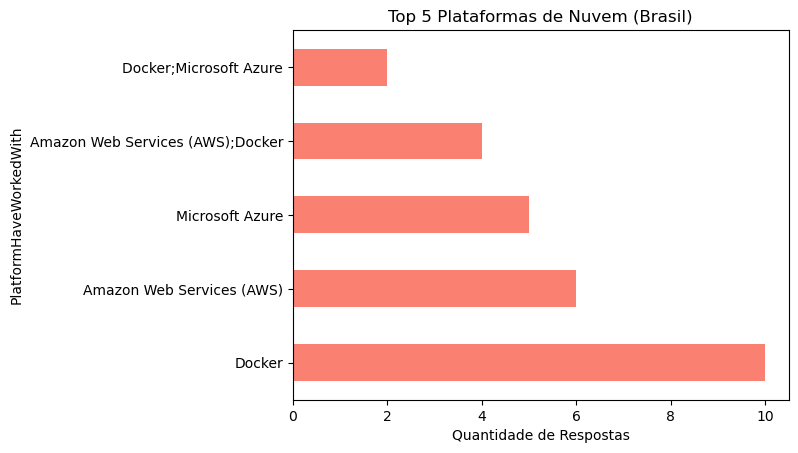

In [19]:
# 1. Contar as plataformas e pegar as 5 principais
nuvem_popular = df_brasil['PlatformHaveWorkedWith'].value_counts().head(5)

print("Principais Plataformas de Nuvem usadas no Brasil:")
print(nuvem_popular)

# 2. Gráfico
nuvem_popular.plot(kind='barh', color='salmon', title='Top 5 Plataformas de Nuvem (Brasil)')
plt.xlabel('Quantidade de Respostas')
plt.show()